In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm import tqdm
import os

In [2]:
rave_sim_dir = Path('/mnt/d/rave-sim-main/rave-sim-main')
simulations_dir = Path('/mnt/d/rave-sim-main/rave-sim-main/output')
scratch_dir = simulations_dir

In [3]:
sys.path.insert(0, str(rave_sim_dir / "big-wave"))
#print(str(rave_sim_dir / "big-wave"))
import multisim
import config
import util

2025-11-25 16:37:55,407 INFO: Setting up simulation
2025-11-25 16:37:55,530 INFO: Finished setting up simulation in /mnt/d/rave-sim-main/rave-sim-main/output/2025/11/20251125_163755461425


output_newa_RC05B_5um_px19.35e-6.txt
N:  33554432


  0%|                                                                                             | 0/1 [00:00<?, ?it/s]

[2025-11-25 16:37:55.720] [info] Running simulation /mnt/d/rave-sim-main/rave-sim-main/output/2025/11/20251125_163755461425/00000000
[2025-11-25 16:37:56.279] [info] Simulating optical element 1/1
[2025-11-25 16:37:56.281] [info] PreciseSample info:
[2025-11-25 16:37:56.281] [info]   z_len: 5020, x_len: 450
[2025-11-25 16:37:56.281] [info]   material_deltabetas size: 5
[2025-11-25 16:37:56.281] [info]   Material 0: (0, 0)
[2025-11-25 16:37:56.281] [info]   Material 1: (3.980028738102861e-05, 3.0221185493735903e-06)
[2025-11-25 16:37:56.281] [info]   Material 2: (9.671815753471284e-06, 1.4084912980618154e-07)
[2025-11-25 16:37:56.282] [info]   Material 3: (3.9232608735641375e-06, 7.95510351844201e-09)
[2025-11-25 16:37:56.282] [info]   Material 4: (6.572810031796121e-06, 1.3530260462610018e-07)


100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [01:03<00:00, 63.49s/it]

[2025-11-25 16:38:58.939] [info] Elapsed time for optical element: 62453.797 ms
[2025-11-25 16:38:58.957] [info] Simulation finished in 68.627578094 seconds
nr sources loaded: 1
nr phase steps: 1
nr detector pixels: 3000


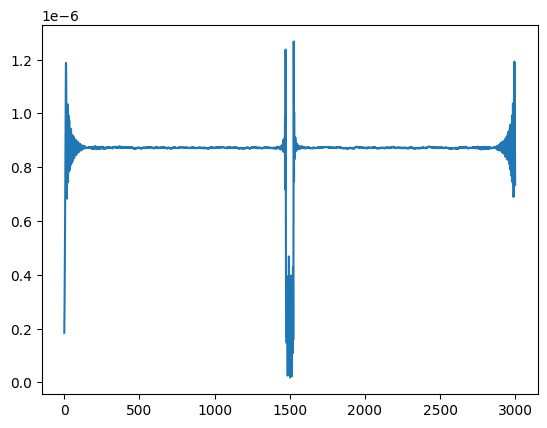

[1.8439074e-07 2.3141676e-07 2.9055059e-07 ... 9.8702037e-07 8.6245348e-07
 7.3430027e-07]


In [4]:
x=[19.35]
for ii in x:
    print('output_newa_RC05B_5um_px'+str(ii)+'e-6.txt')
    config_dict = {
        "sim_params": {
            "N": 2**25,
            "dx": 3.1e-10,
            "z_detector":50/14.35*0.02+1,
            "detector_size": 3e-3,
            "detector_pixel_size_x": 1e-6,
            "detector_pixel_size_y": 1,
            "chunk_size": 512 * 1024 * 1024 // 16,  # use 256MB chunks
        },
        "use_disk_vector": False,
        "save_final_u_vectors": False,
        "dtype": "c8",
        "multisource": {
            "type": "points",
            "energy_range": [8639-25, 8639+25],
            "x_range": [-2e-6,2e-6],
            "z": 0.0,
            "nr_source_points":1,
            "seed": 1,
            # "spectrum": "/mnt/d/rave-sim-main/rave-sim-main/spectrum/spectrum_25keV.h5",
        },
        "elements": [
            # {
            #     "type": "grating",
            #     "pitch": 10e-6,
            #     "dc": [0.5, 0.5],
            #     "z_start": 0.8,
            #     "thickness": 650e-9,
            #     "nr_steps": 1,
            #     "x_positions": [0.0],
            #     "substrate_thickness": 15 * 1e-6,
            #     "mat_a": ["W", 2.33],
            #     "mat_b": ["Au", 0.0],
            #     "mat_substrate": ["Si", 2.34],
            # },
            {
                "type": "sample",
                "z_start": 1,
                # "pixel_size_x": 5 * 1e-6, for precise test
                # "pixel_size_z": 5 * 1e-6,
                "pixel_size_x": 1 * 1e-7, 
                "pixel_size_z": 1 * 1e-7,
                "grid_path":"/mnt/d/rave-sim-main/rave-sim-main/grid/5um_RC05B.npy",
                "materials": [["W",ii],["SiN",3.44],["C10H8O4",1.35],["Si",2.33]],
                "x_positions":[0],
            },
        ],
    }
    
    print("N: ", config_dict["sim_params"]["N"])
    sim_path = multisim.setup_simulation(config_dict, Path("."), simulations_dir)
    computed = config.load(Path(sim_path / 'computed.yaml'))
    for i in tqdm(range(config_dict["multisource"]["nr_source_points"])):
        os.system(f"CUDA_VISIBLE_DEVICES=0 /mnt/d/rave-sim-main/rave-sim-main/fast-wave/build-Release/fastwave -s {i} {sim_path}")
    wavefronts = util.load_wavefronts_filtered(sim_path, x_range=(-7.5e-6, 7.5e-6))
    print("nr sources loaded:", len(wavefronts))
    wavef= [result[0] for result in wavefronts]
    wf = np.sum(wavef, axis=0)
    print("nr phase steps:", wf.shape[0])
    print("nr detector pixels:", wf.shape[1])
    sp = config_dict["sim_params"]
    detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
    plt.plot(wf[0])
    plt.show()
    from contextlib import redirect_stdout
    with open('test_output_RC04_5um_px'+str(ii)+'.txt', 'w') as file:
        with redirect_stdout(file):
            for i in range(len(wf[0])):
                print(wf[0][i])
    print(wf[0])